> >Phace-1            

First I import the libraries that I will use for data cleaning

I load the data using pd.read_csv() and then print the first 5 rows to see what the data looks like

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_data():
    df= pd.read_csv("/kaggle/input/datasets/alghi77/project/AmesHousing.csv")
    
    print("First 5 raw:")
    print(df.head())
    return df

df= load_data()

First 5 raw:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePri

Here I check the number of rows and columns in the data using shape

In [181]:
def check_shape(df):
    print("Dataset shape:",df.shape)
check_shape(df)

Dataset shape: (2930, 82)


I use .info() to see the column types and check if there are any columns of the wrong type

In [182]:
def inspect_types(df):
    print("Types of columns before correction:")
    print(df.info())
inspect_types(df)

Types of columns before correction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 no

I'm changing the type of two columns:

Lot Area-> I'll make it float

Year Built-> I'll change it to datetime

In [183]:
def fix_types(df):
    df["Lot Area"]= df["Lot Area"].astype(float)
    df["Year Built"]= pd.to_datetime(df["Year Built"])
    print("Types of columns after correction:")
    print(df.info())
    return df
df= fix_types(df)

Types of columns after correction:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order            2930 non-null   int64         
 1   PID              2930 non-null   int64         
 2   MS SubClass      2930 non-null   int64         
 3   MS Zoning        2930 non-null   object        
 4   Lot Frontage     2440 non-null   float64       
 5   Lot Area         2930 non-null   float64       
 6   Street           2930 non-null   object        
 7   Alley            198 non-null    object        
 8   Lot Shape        2930 non-null   object        
 9   Land Contour     2930 non-null   object        
 10  Utilities        2930 non-null   object        
 11  Lot Config       2930 non-null   object        
 12  Land Slope       2930 non-null   object        
 13  Neighborhood     2930 non-null   object        
 14  Condi

I am looking for columns that have missing values using .isnull().sum()

In [184]:
def check_missing(df):
    missing= df.isnull().sum().sort_values(ascending=False)
    print("Columns with most missing values:")
    print(missing.head(10))
check_missing(df)

Columns with most missing values:
Pool QC          2917
Misc Feature     2824
Alley            2732
Fence            2358
Mas Vnr Type     1775
Fireplace Qu     1422
Lot Frontage      490
Garage Qual       159
Garage Yr Blt     159
Garage Cond       159
dtype: int64


For the numeric columns fill them with median

For the text columns fill them with None as some houses don't have this feature

In [185]:
def handle_missing(df):
    num_cols= df.select_dtypes(include=["int64", "float64"]).columns
    cat_cols= df.select_dtypes(include=["object"]).columns
    
    for col in num_cols:
        median= df[col].median()
        df[col]= df[col].fillna(median)
    
    for col in cat_cols:
        df[col]= df[col].fillna("N/a")
    
    print("Total missing values after cleaning:", 
          df.isnull().sum())
    return df

df= handle_missing(df)

Total missing values after cleaning: Order             0
PID               0
MS SubClass       0
MS Zoning         0
Lot Frontage      0
                 ..
Mo Sold           0
Yr Sold           0
Sale Type         0
Sale Condition    0
SalePrice         0
Length: 82, dtype: int64


I check if there are duplicate rows in the data using duplicated()

In [186]:
def check_duplicates(df):
    duplicates = df.duplicated().sum()
    print("Number of duplicates:",duplicates)
    return duplicates
check_duplicates(df)

Number of duplicates: 0


np.int64(0)

If there are duplicate rows delete them using drop_duplicates()

In [187]:
def remove_duplicates(df):
    df= df.drop_duplicates()
    print("Duplicates removed")
    return df
df= remove_duplicates(df)

Duplicates removed


Check for outlirs values in the SalePrice column using boxplot

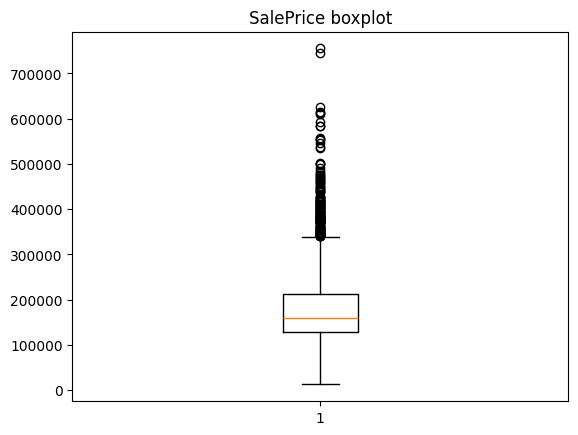

In [188]:
def show_outliers(df):
    plt.boxplot(df["SalePrice"])
    plt.title("SalePrice boxplot")
    plt.show()
show_outliers(df)

I deal with extreme values by setting the upper limit at the 99th percentile

In [189]:
def cap_outliers(df):
    cap= df["SalePrice"].quantile(0.99)
    df["SalePrice"]= df["SalePrice"].apply(lambda x: cap if x > cap else x)
    print("Outliers capped at 99 percentile")
    return df
df= cap_outliers(df)

Outliers capped at 99 percentile


I combine all the previous cleaning steps into one function so that I can reuse them

Finallyyy three more checks were added to ensure that the data was clean

First 5 raw:
   Order        PID  MS SubClass MS Zoning  Lot Frontage  Lot Area Street  \
0      1  526301100           20        RL         141.0     31770   Pave   
1      2  526350040           20        RH          80.0     11622   Pave   
2      3  526351010           20        RL          81.0     14267   Pave   
3      4  526353030           20        RL          93.0     11160   Pave   
4      5  527105010           60        RL          74.0     13830   Pave   

  Alley Lot Shape Land Contour  ... Pool Area Pool QC  Fence Misc Feature  \
0   NaN       IR1          Lvl  ...         0     NaN    NaN          NaN   
1   NaN       Reg          Lvl  ...         0     NaN  MnPrv          NaN   
2   NaN       IR1          Lvl  ...         0     NaN    NaN         Gar2   
3   NaN       Reg          Lvl  ...         0     NaN    NaN          NaN   
4   NaN       IR1          Lvl  ...         0     NaN  MnPrv          NaN   

  Misc Val Mo Sold Yr Sold Sale Type  Sale Condition  SalePri

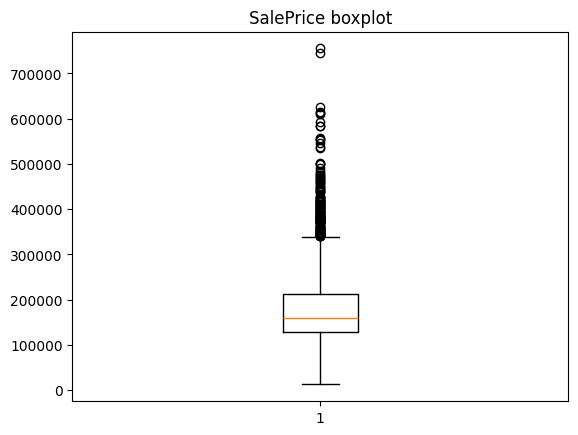

Outliers capped at 99 percentile


In [190]:
def clean_data():
    df= load_data()  
    check_shape(df)
    inspect_types(df)
    df= fix_types(df)
    check_missing(df)
    df= handle_missing(df)
    check_duplicates(df)
    df= remove_duplicates(df)
    show_outliers(df)
    df= cap_outliers(df)
    return df
    
df= clean_data()

In [191]:
def final_checks(df):
    print("Check1: nulls in SalePrice")
    print(df["SalePrice"].isnull().sum())

    print("Check2: SalePrice > 0")
    print((df["SalePrice"]<= 0).sum())

    print("Check 3: number of columns")
    print(len(df.columns))


final_checks(df)

Check1: nulls in SalePrice
0
Check2: SalePrice > 0
0
Check 3: number of columns
82
